# Tema : Modelos ARIMA - SARIMA

![](src/img/logo_utb.png){width=40%}
![](src/img/logo_etd.png){width=40%}
- **Profesor:**
- **Fernando Salcedo Mejía, Eco Msc.**
- Programa de Ciencias de Datos | Escuela de transformación digital.
- 2026-1

# Ejercicio 1. Pronostico del PIB de Colombia.

- Usando los datos del Banco Mundial, estime un modelo ARIMA válido acorde a la teoría entre 1960-2024. Finalmente, realice el pronostico del PIB de Colombia para los próximos 5 años.



In [8]:
# Librerias necesarias

# Datos
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import wbgapi as wb

# Modelos de tiempo
import statsmodels.api as sm
from statsmodels.tsa.arima.model import ARIMA
from pmdarima import auto_arima

# Estadisticos
from scipy import stats
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.stats.diagnostic import acorr_ljungbox
from statsmodels.tsa.stattools import adfuller, kpss
from statsmodels.stats.stattools import jarque_bera, durbin_watson
from statsmodels.stats.diagnostic import het_breuschpagan, het_white
from statsmodels.nonparametric.smoothers_lowess import lowess
from sklearn.metrics import r2_score

import warnings
warnings.filterwarnings('ignore')


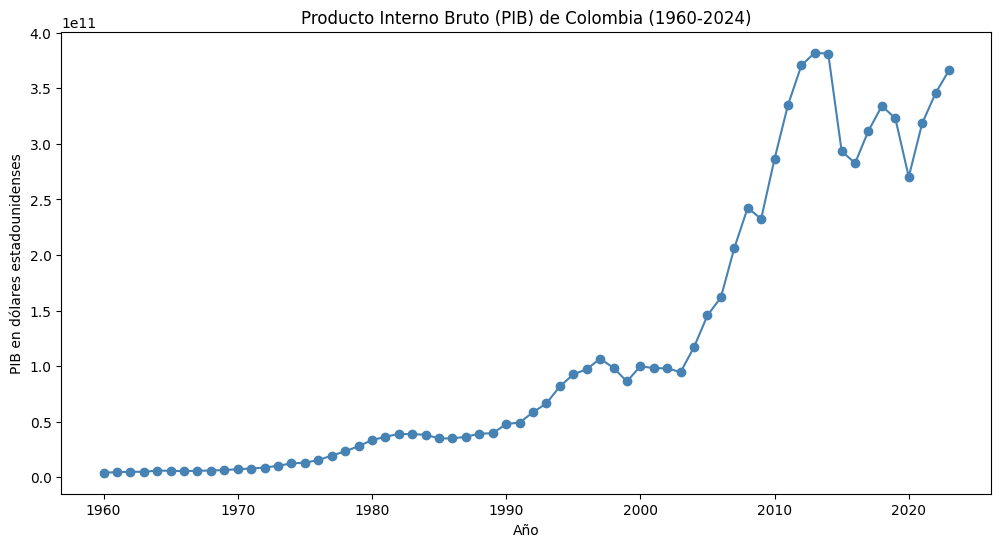

In [9]:
## Descargar los datos del Banco Mundial
data = wb.data.DataFrame(series='NY.GDP.MKTP.CD', economy='COL', time=range(1960, 2024), columns='series').reset_index()
data.columns = ['year', 'pib']
data['year'] = data['year'].str.replace('YR', '').astype(int)
data = data.set_index('year')
pib_col = data['pib']

fig, ax = plt.subplots(figsize=(12, 6))
ax.plot(data.index, pib_col, marker='o', color='steelblue')
ax.set_title('Producto Interno Bruto (PIB) de Colombia (1960-2024)')
ax.set_xlabel('Año')
ax.set_ylabel('PIB en dólares estadounidenses')
plt.show()


## Verificar estacionaridad de la serie original

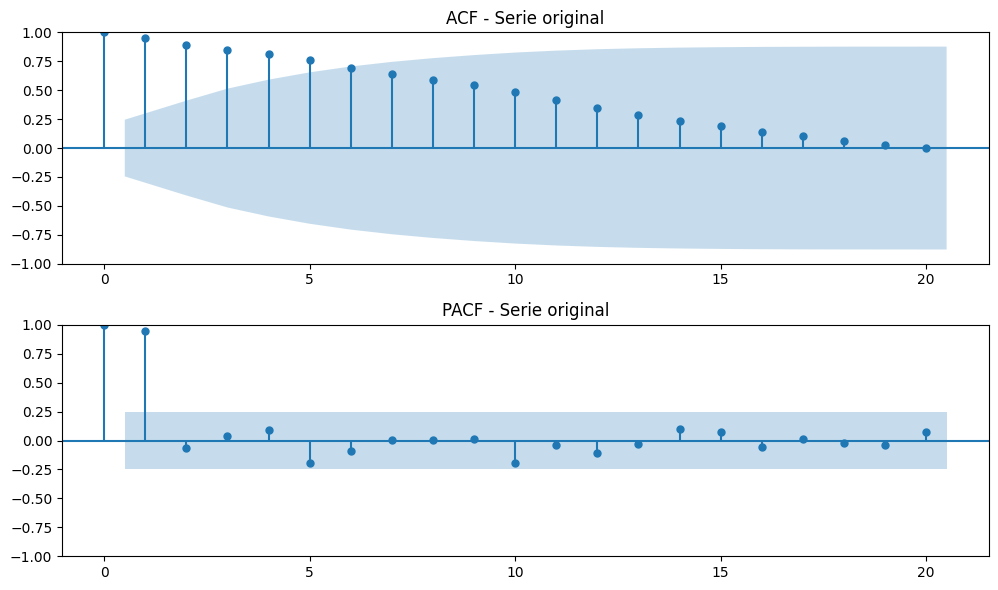

In [10]:
# Graficar la funcion de ACF y PACF
def graficar_autocorrelacion(data, title, maxlag = 20):
    fig, axes = plt.subplots(2, 1, figsize=(10, 6))
    plot_acf(data, lags=maxlag, ax=axes[0], title=f'ACF - {title}')
    plot_pacf(data, lags=maxlag, ax=axes[1], title=f'PACF - {title}')
    plt.tight_layout()
    plt.show()

graficar_autocorrelacion(pib_col, title= "Serie original")

In [11]:
def test_autocorrelacion(datos, n_lags=20):
    # Ljung-Box (Prueba global)
    lb_test        = acorr_ljungbox(datos, lags=n_lags, return_df=True)
    min_p_value    = lb_test['lb_pvalue'].min()
    lb_stat        = lb_test.loc[lb_test['lb_pvalue'] == min_p_value, 'lb_stat'].iloc[0]

    # Durbin-Watson (Autocorrelación de primer orden)
    dw_stat = durbin_watson(datos)

    # Tabla de resultados
    tab_test = pd.DataFrame({
        'Test'        : ["Durbin-Watson", f"Ljung-Box (hasta lag {n_lags})"],
        'Estadístico' : [round(dw_stat, 4), round(lb_stat, 4)],
        'P-valor'     : [None, round(min_p_value, 4)]
    })

    # Conclusiones
    dw_conclu = (
        "Sin autocorrelación" if 1.5 < dw_stat < 2.5 else
        "Autocorrelación positiva" if dw_stat < 1.5 else
        "Autocorrelación negativa"
    )
    lb_conclu = "Sin autocorrelación" if min_p_value > 0.05 else "Autocorrelación detectada"
    tab_test['Conclusión'] = [dw_conclu, lb_conclu]

    print("=" * 80)
    print("PRUEBA DE LJUNG-BOX Y DURBIN-WATSON")
    print("=" * 80)
    print(tab_test)
    print("=" * 80)

test_autocorrelacion(pib_col, n_lags=20)

PRUEBA DE LJUNG-BOX Y DURBIN-WATSON
                       Test  Estadístico  P-valor                 Conclusión
0             Durbin-Watson       0.0152      NaN   Autocorrelación positiva
1  Ljung-Box (hasta lag 20)     418.2162      0.0  Autocorrelación detectada


In [12]:
def test_estacionariedad(datos):
    # Augmented Dickey-Fuller
    adf_result = adfuller(datos)
    # KPSS
    kpss_result = kpss(datos, regression='c')

    # Tabla de resultados
    tab_test = pd.DataFrame({
        'Test'        : ["Prueba Augmented Dickey-Fuller (ADF)", "Prueba KPSS"],
        'Estadístico' : [round(adf_result[0],  4), round(kpss_result[0],  4)],
        'P-valor'     : [round(adf_result[1], 4), round(kpss_result[1], 4)],
        "Estacionario" : ["Sí" if adf_result[1] < 0.05 else "No", "No" if kpss_result[1] < 0.05 else "Sí"]
    })

    print("=" * 80)
    print("PRUEBA DE ESTACIONARIEDAD")
    print("=" * 80)
    print(tab_test)
    print("=" * 80)


test_estacionariedad(pib_col)

PRUEBA DE ESTACIONARIEDAD
                                   Test  Estadístico  P-valor Estacionario
0  Prueba Augmented Dickey-Fuller (ADF)       2.7717     1.00           No
1                           Prueba KPSS       0.9984     0.01           No


## Integración de la serie para estacionaridad

- Para integrar una serie con el fin de estabilizar la media y la varianza sacamos su primera diferencia

1. $E[Y_t] = \mu$ (constante) $\forall t$
2. $Var(Y_t) = \sigma^2$ (constante) $\forall t$
3. $Cov(Y_t, Y_{t+k}) = \gamma_k$ (solo depende del rezago $k$)

$$
\Delta y_t = y_t - y_{t-1}
$$

## Transformaciones usuales en las series económicas 

- Es usual transformar la series económicas en términos de crecimiento porcentual aplicando logaritmos y posterior tomar su primera diferencia que es equivalente a incremento porcentual.
- Como vimos en la transformación de Box-Cox (λ=0), el logaritmo ayuda a linealizar funciones exponenciales y varianza creciente.

$$
\Delta \log{y_t} = \log{y_t} - \log{y_{t-1}} = \log{\frac{y_t}{y_{t-1}}} \sim \%\Delta y_t
$$

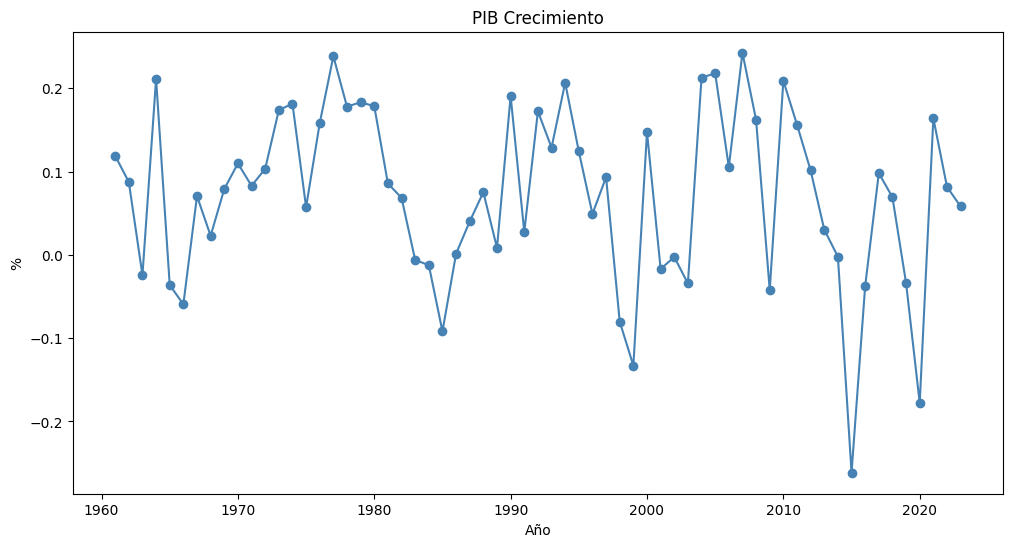

In [13]:
# Primera diferencia de la serie integrada de orden 1
pib_diff = pib_col.diff().dropna()

# Tomamos el logaritmo y la primera diferencia. Esto transforma la serie en tasas de crecimiento
pib_log = np.log(pib_col)
pib_crecimiento = pib_log.diff().dropna()

fig, ax = plt.subplots(figsize=(12, 6))
ax.plot(pib_crecimiento, marker='o', color='steelblue')
ax.set_title('PIB Crecimiento')
ax.set_xlabel('Año')
ax.set_ylabel('%')
plt.show()


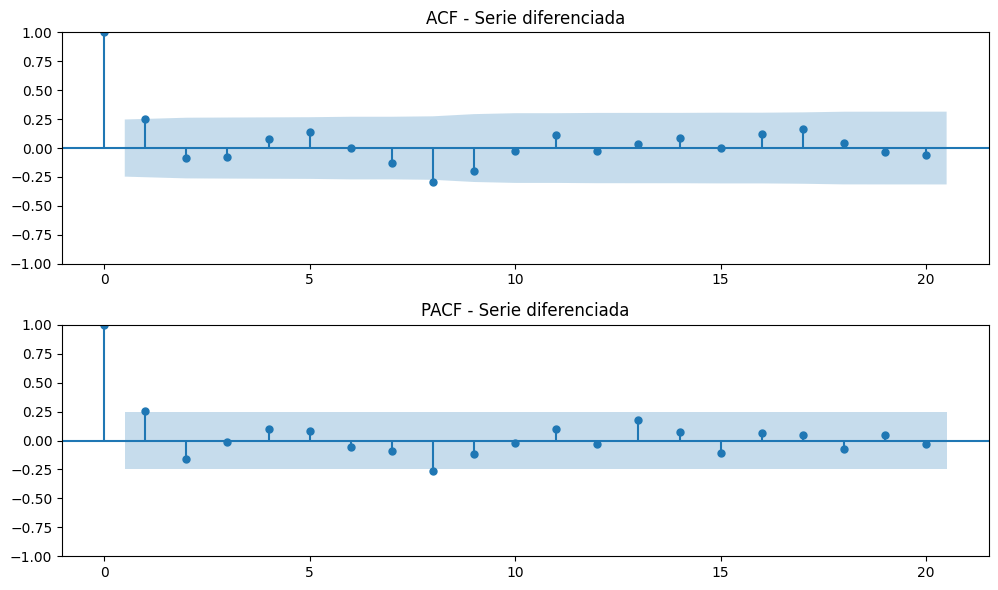

PRUEBA DE ESTACIONARIEDAD
                                   Test  Estadístico  P-valor Estacionario
0  Prueba Augmented Dickey-Fuller (ADF)      -5.9457      0.0           Sí
1                           Prueba KPSS       0.2410      0.1           Sí


In [14]:
# Graficar la funcion de ACF y PACF de la serie diferenciada
graficar_autocorrelacion(pib_diff, title="Serie diferenciada")

# Test estacionariedad
test_estacionariedad(pib_diff)

## Estimación modelos ARIMA

In [15]:
# ARIMA(1, 1, 0)
m_arima110 = ARIMA(pib_crecimiento, order = (1, 0, 0)).fit()
print(m_arima110.summary())

# guardar modelos estimados
modelos = {}
modelos["ARIMA(1, 1, 0)"] = m_arima110

                               SARIMAX Results                                
Dep. Variable:                    pib   No. Observations:                   63
Model:                 ARIMA(1, 0, 0)   Log Likelihood                  55.505
Date:                Fri, 10 Apr 2026   AIC                           -105.010
Time:                        15:38:44   BIC                            -98.581
Sample:                             0   HQIC                          -102.481
                                 - 63                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.0718      0.020      3.657      0.000       0.033       0.110
ar.L1          0.2795      0.128      2.187      0.029       0.029       0.530
sigma2         0.0100      0.002      5.751      0.0

In [16]:
# ARIMA(0, 1, 1)
m_arima011 = ARIMA(pib_crecimiento, order = (0, 0, 1)).fit()
print(m_arima011.summary())

# guardar
modelos["ARIMA(0, 1, 1)"] = m_arima011

                               SARIMAX Results                                
Dep. Variable:                    pib   No. Observations:                   63
Model:                 ARIMA(0, 0, 1)   Log Likelihood                  55.215
Date:                Fri, 10 Apr 2026   AIC                           -104.430
Time:                        15:38:44   BIC                            -98.000
Sample:                             0   HQIC                          -101.901
                                 - 63                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.0717      0.018      4.070      0.000       0.037       0.106
ma.L1          0.2578      0.131      1.972      0.049       0.002       0.514
sigma2         0.0101      0.002      5.765      0.0

In [17]:
# ARIMA(1, 1, 1)
m_arima111 = ARIMA(pib_crecimiento, order = (1, 0, 1)).fit()
print(m_arima111.summary())

# guardar
modelos["ARIMA(1, 1, 1)"] = m_arima111

                               SARIMAX Results                                
Dep. Variable:                    pib   No. Observations:                   63
Model:                 ARIMA(1, 0, 1)   Log Likelihood                  55.756
Date:                Fri, 10 Apr 2026   AIC                           -103.512
Time:                        15:38:44   BIC                            -94.939
Sample:                             0   HQIC                          -100.140
                                 - 63                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.0719      0.023      3.130      0.002       0.027       0.117
ar.L1          0.5701      0.413      1.379      0.168      -0.240       1.380
ma.L1         -0.3204      0.469     -0.683      0.4

In [18]:
# Auto-ARIMA encuentra los parámetros óptimos automáticamente
m_autoARIMA = auto_arima(pib_crecimiento, 
                         seasonal=False,      # No seasonal
                         stepwise=True,       # Búsqueda por pasos
                         trace=True,          # Mostrar progreso
                         error_action='ignore',
                         suppress_warnings=True,
                         start_p=0, start_q=0, max_p=5, max_q=5, d=0)

print("Auto-ARIMA")
print(m_autoARIMA.summary())
print(f'Parámetros óptimos: ARIMA{m_autoARIMA.order}')

modelos["auto-ARIMA"] = ARIMA(pib_crecimiento, order = (1, 0, 0), trend="c").fit()


Performing stepwise search to minimize aic
 ARIMA(0,0,0)(0,0,0)[0]             : AIC=-79.573, Time=0.02 sec
 ARIMA(1,0,0)(0,0,0)[0]             : AIC=-96.161, Time=0.00 sec
 ARIMA(0,0,1)(0,0,0)[0]             : AIC=-90.520, Time=0.04 sec
 ARIMA(2,0,0)(0,0,0)[0]             : AIC=-96.649, Time=0.03 sec
 ARIMA(3,0,0)(0,0,0)[0]             : AIC=-98.066, Time=0.07 sec
 ARIMA(4,0,0)(0,0,0)[0]             : AIC=-96.221, Time=0.07 sec
 ARIMA(3,0,1)(0,0,0)[0]             : AIC=-96.190, Time=0.07 sec
 ARIMA(2,0,1)(0,0,0)[0]             : AIC=-97.191, Time=0.07 sec
 ARIMA(4,0,1)(0,0,0)[0]             : AIC=-94.270, Time=0.17 sec
 ARIMA(3,0,0)(0,0,0)[0] intercept   : AIC=-102.353, Time=0.20 sec
 ARIMA(2,0,0)(0,0,0)[0] intercept   : AIC=-103.241, Time=0.02 sec
 ARIMA(1,0,0)(0,0,0)[0] intercept   : AIC=-105.010, Time=0.03 sec
 ARIMA(0,0,0)(0,0,0)[0] intercept   : AIC=-101.815, Time=0.00 sec
 ARIMA(1,0,1)(0,0,0)[0] intercept   : AIC=-103.512, Time=0.05 sec
 ARIMA(0,0,1)(0,0,0)[0] intercept   : AIC=

In [19]:
def comparar_modelos_arima(modelos: dict) -> pd.DataFrame:
    df_modelos = (
        pd.DataFrame({
            "Modelo"  : list(modelos),
            "AIC"     : [m.aic       for m in modelos.values()],
            "AICc"    : [m.aicc      for m in modelos.values()],
            "BIC"     : [m.bic       for m in modelos.values()],
            "Log-Lik" : [m.llf       for m in modelos.values()],
            "MSE"     : [m.mse       for m in modelos.values()],
            "RMSE"    : [m.mse**0.5  for m in modelos.values()],
            "MAE"     : [m.mae       for m in modelos.values()],
            "Params"  : [m.df_model  for m in modelos.values()],
            "Obs"     : [m.nobs      for m in modelos.values()],
        })
        .sort_values("AICc")
        .assign(Ranking=lambda df: range(1, len(df) + 1))
        .set_index("Ranking")
    )

    mejor      = df_modelos.iloc[0]["Modelo"]
    mejor_aicc = df_modelos.iloc[0]["AICc"]

    print("=" * 100)
    print("COMPARACIÓN DE MODELOS ARIMA")
    print("=" * 100)
    print(df_modelos.to_string())
    print("-" * 100)
    print(f"Mejor modelo (menor AICc): {mejor}  →  AICc: {mejor_aicc}")
    print("=" * 100)

comparar_modelos_arima(modelos)

mejor_modelo = modelos['ARIMA(1, 1, 0)']

COMPARACIÓN DE MODELOS ARIMA
                 Modelo         AIC        AICc        BIC    Log-Lik       MSE      RMSE       MAE  Params  Obs
Ranking                                                                                                         
1        ARIMA(1, 1, 0) -105.010140 -104.603360 -98.580736  55.505070  0.010042  0.100211  0.078546       3   63
2            auto-ARIMA -105.010140 -104.603360 -98.580736  55.505070  0.010042  0.100211  0.078546       3   63
3        ARIMA(0, 1, 1) -104.429871 -104.023091 -98.000467  55.214935  0.010137  0.100681  0.078878       3   63
4        ARIMA(1, 1, 1) -103.511512 -102.821857 -94.938973  55.755756  0.009960  0.099802  0.078475       4   63
----------------------------------------------------------------------------------------------------
Mejor modelo (menor AICc): ARIMA(1, 1, 0)  →  AICc: -104.60336018256797


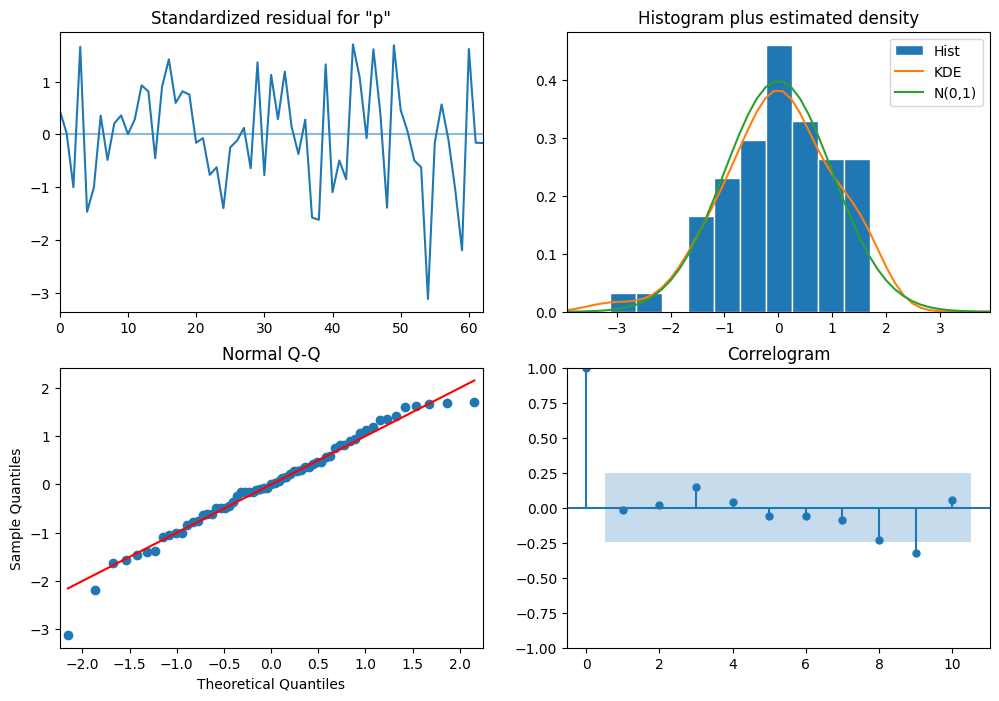

PRUEBA DE LJUNG-BOX Y DURBIN-WATSON
                       Test  Estadístico  P-valor           Conclusión
0             Durbin-Watson       2.0231      NaN  Sin autocorrelación
1  Ljung-Box (hasta lag 20)      26.6033   0.0641  Sin autocorrelación


In [20]:
# Verificar ruido blanco
# Diagnostico del modelo
def plot_diagnostics(modelo, n_lags=10):
    if not "statsmodels" in str(type(modelo)):
        raise TypeError("El objeto debe ser un modelo ajustado de statsmodels.")

    # Diagnóstico
    modelo.plot_diagnostics(figsize=(12,8))
    plt.show()

    # test_autocorrelacion
    test_autocorrelacion(modelo.resid, n_lags=n_lags)

# Ejecución de la función
plot_diagnostics(modelo = mejor_modelo, n_lags=20)


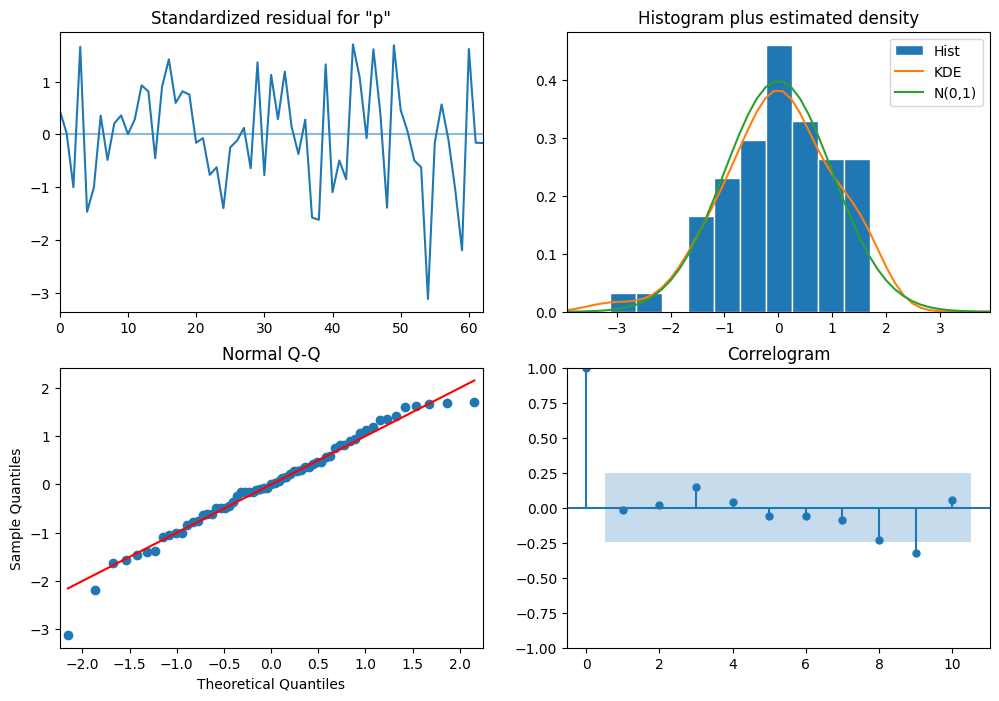

PRUEBA DE LJUNG-BOX Y DURBIN-WATSON
                       Test  Estadístico  P-valor           Conclusión
0             Durbin-Watson       2.0231      NaN  Sin autocorrelación
1  Ljung-Box (hasta lag 20)      26.6033   0.0641  Sin autocorrelación


In [21]:
# Verificar ruido blanco
plot_diagnostics(modelo = mejor_modelo, n_lags=20)

## Pronóstico mejor modelo modelo crecimiento PIB

Acorde al DANE En 2024p, el Producto Interno Bruto (PIB) presenta un crecimiento de 1,5% respecto a 2023. El modelo pronosticó 0,68% de incremento para 2024 respecto a 2023.
https://www.dane.gov.co/index.php/estadisticas-por-tema/cuentas-nacionales/cuentas-nacionales-anuales

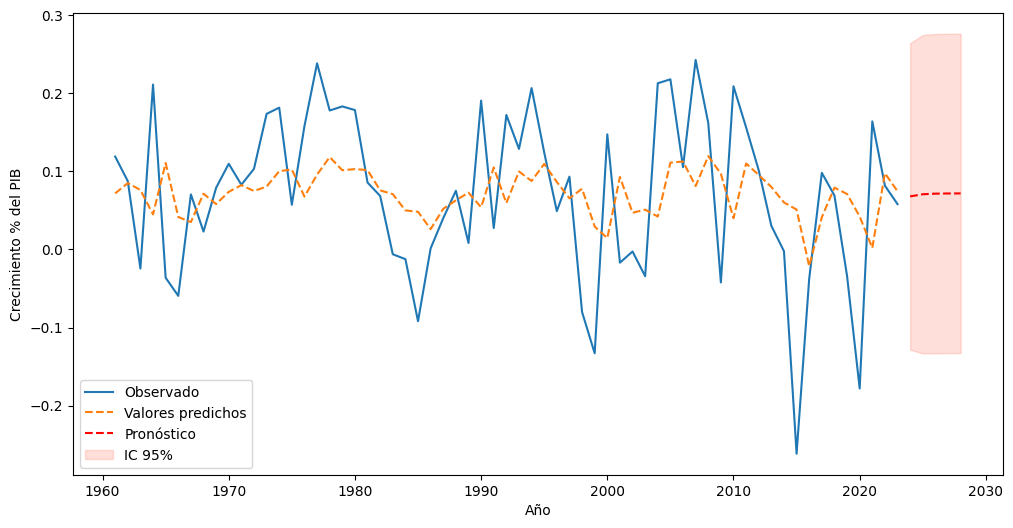

      Pronóstico  IC Inferior  IC Superior
Año                                       
2024    0.067946    -0.128430     0.264322
2025    0.070711    -0.133192     0.274613
2026    0.071483    -0.132996     0.275962
2027    0.071699    -0.132825     0.276223
2028    0.071760    -0.132768     0.276287


In [22]:
# Pronostico de los proximos 5 años
t_pronostico = 5
ultimo_anio  = pib_crecimiento.index[-1]
anio_pronostico = range(ultimo_anio + 1, ultimo_anio + 1 + t_pronostico)

# Obtener valores promedios e intervalos del pronostico
pronostico_pib = mejor_modelo.get_forecast(steps=t_pronostico)
pred_mean = pronostico_pib.predicted_mean
pred_ci = pronostico_pib.conf_int()

# Alinear índice con la serie original
pred_mean.index = anio_pronostico
pred_ci.index   = anio_pronostico

# Graficar resultados pronostico
plt.figure(figsize=(12, 6))
ax = pib_crecimiento.plot(label = "Observado")
plt.plot(mejor_modelo.fittedvalues.index, mejor_modelo.fittedvalues, label = "Valores predichos", linestyle = "--")
pred_mean.plot(ax = ax, label = "Pronóstico", linestyle = "--", color = "red")
ax.fill_between(
    pred_ci.index,
    pred_ci.iloc[:, 0],
    pred_ci.iloc[:, 1],
    color='tomato', alpha=.2, label="IC 95%"
)
ax.set_xlabel('Año')
ax.set_ylabel('Crecimiento % del PIB')
ax.legend()
plt.show()

# Tabla de pronóstico 
df_forecast = pd.DataFrame({
    "Pronóstico" : pred_mean,
    "IC Inferior" : pred_ci.iloc[:, 0],
    "IC Superior" : pred_ci.iloc[:, 1]
})
df_forecast.index.name = "Año"
print(df_forecast.to_string())


## Pronostico en sus niveles del PIB

- Reversar la transformación logarítmico del crecimiento
$$
\Delta \log(PIB_t) = \log(PIB_t) - \log(PIB_{t-1})  \\
PIB_{t+h} = PIB_{t} * \exp^{\sum^{h}_{i=1}\Delta \log(PIB_t)}
$$


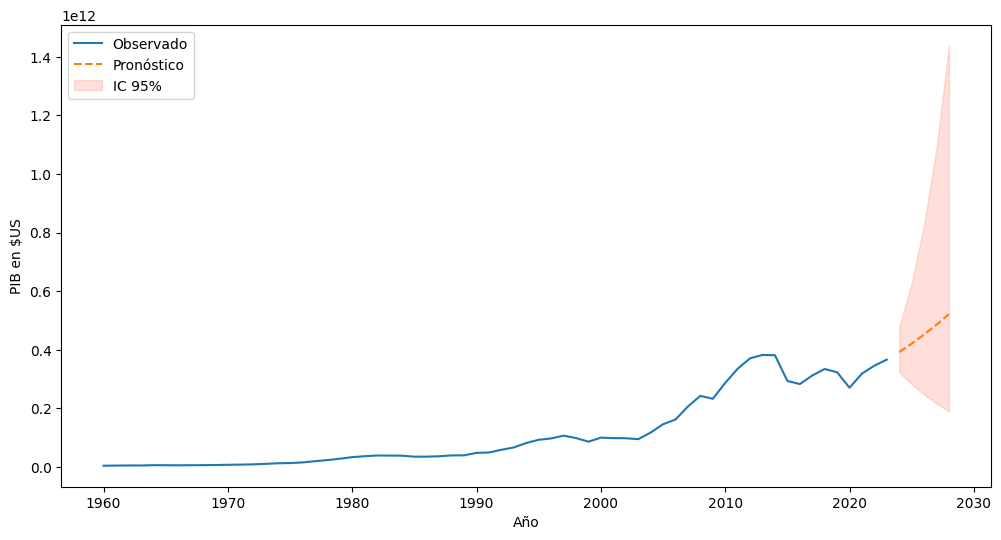

        Pronóstico   IC Inferior   IC Superior
Año                                           
2024  3.920448e+11  3.221444e+11  4.771126e+11
2025  4.207702e+11  2.819720e+11  6.278905e+11
2026  4.519493e+11  2.468577e+11  8.274331e+11
2027  4.855438e+11  2.161531e+11  1.090675e+12
2028  5.216668e+11  1.892785e+11  1.437756e+12


In [23]:
# Revertir log-diferencia a niveles
ultimo_pib_nivel = pib_col.iloc[-1]

pred_niveles     = ultimo_pib_nivel * np.exp(pred_mean.cumsum())
pred_ci_niveles  = pd.DataFrame({
    "lower": ultimo_pib_nivel * np.exp(pred_ci.iloc[:, 0].cumsum()),
    "upper": ultimo_pib_nivel * np.exp(pred_ci.iloc[:, 1].cumsum())
}, index=pred_mean.index)

# Graficar resultados pronostico
plt.figure(figsize=(12, 6))
ax = pib_col.plot(label = "Observado")
pred_niveles.plot(ax = ax, label = "Pronóstico", linestyle = "--")
ax.fill_between(
    pred_ci_niveles.index,
    pred_ci_niveles["lower"],
    pred_ci_niveles["upper"],
    color="tomato", alpha=0.2, label="IC 95%"
)
ax.set_xlabel('Año')
ax.set_ylabel('PIB en $US')
ax.legend()
plt.show()

# Tabla de pronóstico en niveles
df_forecast = pd.DataFrame({
    "Pronóstico" : pred_niveles,
    "IC Inferior" : pred_ci_niveles["lower"],
    "IC Superior" : pred_ci_niveles["upper"],
})
df_forecast.index.name = "Año"
print(df_forecast.to_string())


# Ejemplo 2. Empleo mensual en el sector de ocio y hostelería en EE. UU

Describiremos la modelización ARIMA estacional utilizando datos mensuales de empleo en Estados Unidos para los trabajos de ocio y hospitalidad desde enero de 2001 hasta septiembre de 2019.

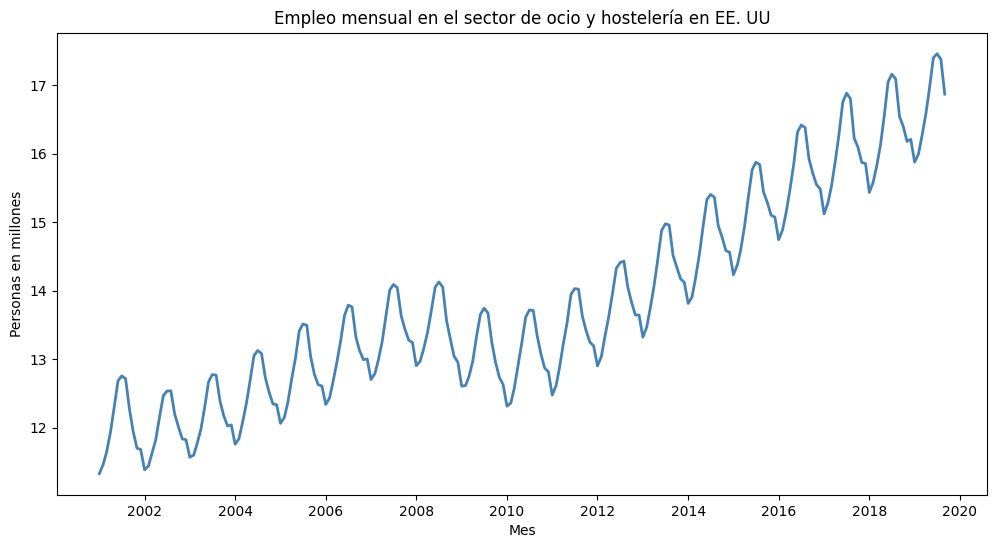

In [24]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from statsmodels.tsa.stattools import adfuller, kpss
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.stats.diagnostic import acorr_ljungbox
from statsmodels.tsa.arima.model import ARIMA
from pmdarima import auto_arima
from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.stats.stattools import jarque_bera, durbin_watson
import warnings
warnings.filterwarnings('ignore')

# leer y ajustar datos
datos = pd.read_csv("data/us_employment.csv", parse_dates=["ds"])
datos = datos.loc[(datos["ds"] >= "2001-01-01") & (datos["unique_id"] == "Leisure and Hospitality")].reset_index(drop=True)
datos["y"] = datos["y"] / 1e3
datos = datos.set_index('ds')
datos.index = pd.DatetimeIndex(datos.index).to_period('M').to_timestamp()
serie_us_employment = datos.y

# grafico serie
plt.figure(figsize=(12, 6))
plt.plot(serie_us_employment.index, serie_us_employment, color='steelblue', linewidth=2)
plt.xlabel('Mes')
plt.ylabel('Personas en millones')
plt.title('Empleo mensual en el sector de ocio y hostelería en EE. UU')
plt.show()

Los datos son claramente no estacionarios, con una fuerte estacionalidad y una tendencia no lineal, por lo que primero tomaremos una diferencia estacional. Los datos con diferencia estacional se muestran en la figura siguiente.


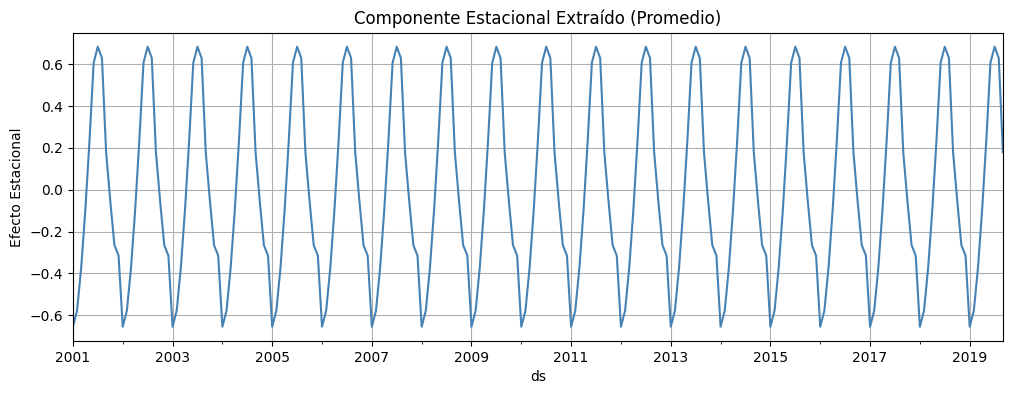

In [25]:

# Descomposición aditiva
descomposicion = seasonal_decompose(serie_us_employment, model='additive')

# Graficar solo el componente estacional
plt.figure(figsize=(12, 4))
descomposicion.seasonal.plot(color='steelblue')
plt.title('Componente Estacional Extraído (Promedio)')
plt.ylabel('Efecto Estacional')
plt.grid(True)
plt.show()

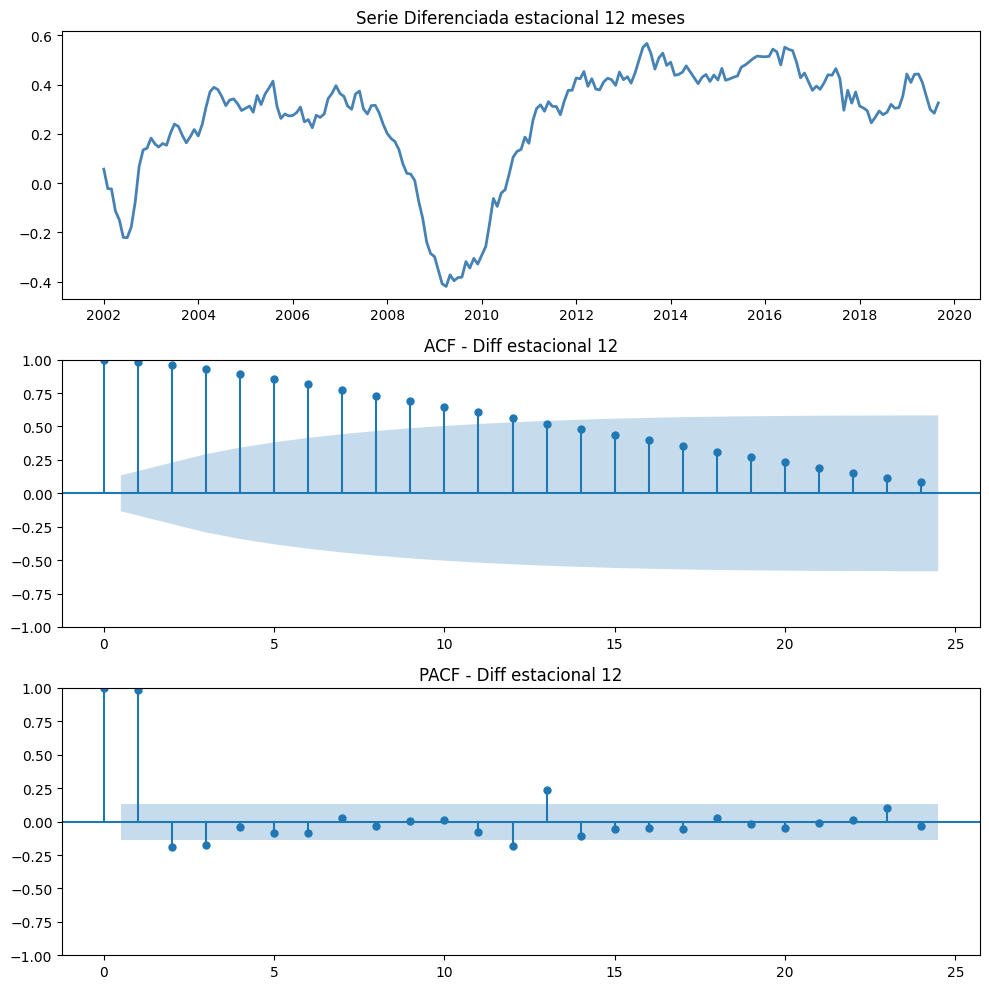

In [26]:
# Diferencia estacional
diff_s12_serie_us_employment = serie_us_employment.diff(12).dropna()

fig, axes = plt.subplots(3, 1, figsize=(10, 10))
axes[0].plot(diff_s12_serie_us_employment.index, diff_s12_serie_us_employment, color='steelblue', linewidth=2)
axes[0].set_title('Serie Diferenciada estacional 12 meses')
plot_acf(diff_s12_serie_us_employment, ax=axes[1], title=f'ACF - Diff estacional 12')
plot_pacf(diff_s12_serie_us_employment, ax=axes[2], title=f'PACF - Diff estacional 12')
plt.tight_layout()
plt.show()

Estos también son claramente no estacionarios, por lo que tomamos una primera diferencia adicional, ver figura siguiente.

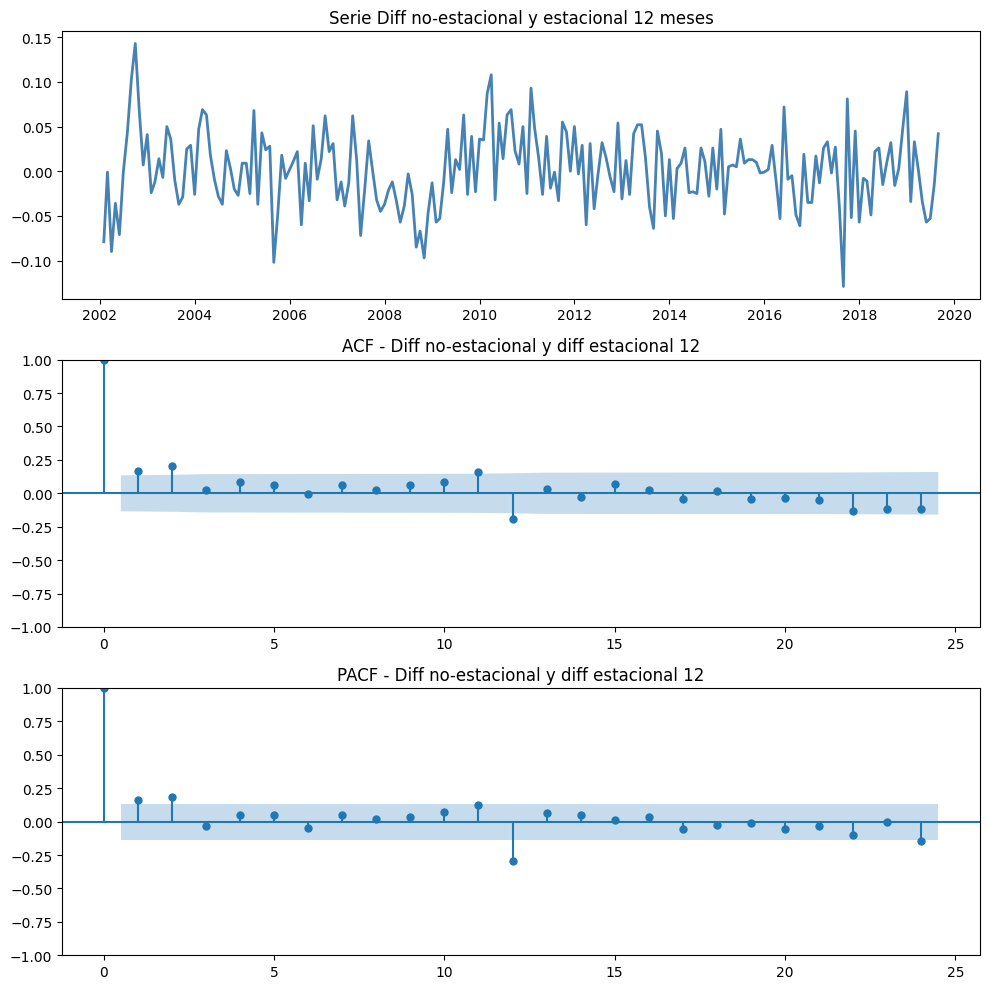

In [27]:
ddiff_s12_serie_us_employment = diff_s12_serie_us_employment.diff().dropna()

fig, axes = plt.subplots(3, 1, figsize=(10, 10))
axes[0].plot(ddiff_s12_serie_us_employment.index, ddiff_s12_serie_us_employment, color='steelblue', linewidth=2)
axes[0].set_title('Serie Diff no-estacional y estacional 12 meses')
plot_acf(ddiff_s12_serie_us_employment, ax=axes[1], title=f'ACF - Diff no-estacional y diff estacional 12')
plot_pacf(ddiff_s12_serie_us_employment, ax=axes[2], title=f'PACF - Diff no-estacional y diff estacional 12')
plt.tight_layout()
plt.show()

In [28]:
def test_estacionariedad(datos):
    # Augmented Dickey-Fuller
    adf_result = adfuller(datos)
    # KPSS
    kpss_result = kpss(datos, regression='c')

    # Tabla de resultados
    tab_test = pd.DataFrame({
        'Test'        : ["Prueba Augmented Dickey-Fuller (ADF)", "Prueba KPSS"],
        'Estadístico' : [round(adf_result[0],  4), round(kpss_result[0],  4)],
        'P-valor'     : [round(adf_result[1], 4), round(kpss_result[1], 4)],
        "Estacionario" : ["Sí" if adf_result[1] < 0.05 else "No", "No" if kpss_result[1] < 0.05 else "Sí"]
    })

    print("=" * 80)
    print("PRUEBA DE ESTACIONARIEDAD")
    print("=" * 80)
    print(tab_test)
    print("=" * 80)


test_estacionariedad(ddiff_s12_serie_us_employment)

PRUEBA DE ESTACIONARIEDAD
                                   Test  Estadístico  P-valor Estacionario
0  Prueba Augmented Dickey-Fuller (ADF)      -3.8213   0.0027           Sí
1                           Prueba KPSS       0.0804   0.1000           Sí


## Definición del modelo
- Nuestro objetivo ahora es encontrar un modelo ARIMA apropiado basándonos en la ACF y la PACF mostradas en la figura anterior. 
- El pico significativo en el rezago 2 de la ACF sugiere un componente MA(2) no estacional. 
- El pico significativo en el rezago 12 de la ACF sugiere un componente MA(1) estacional. 
- En consecuencia, comenzamos con un modelo $ARIMA(0,1,2)(0,1,1)_12$, que indica una primera diferencia, una diferencia estacional y componentes MA(2) no estacional y MA(1) estacional. 
- Si hubiéramos partido de la PACF, podríamos haber seleccionado un modelo $ARIMA(2,1,0)(0,1,1)_12$
- Usando la PACF para seleccionar la parte no estacional del modelo y la ACF para seleccionar la parte estacional. También incluiremos un modelo seleccionado automáticamente.

## Construcción del modelo SARIMA (0,1,2)(0,1,1)12​
- Parte Regular (0,1,2):
    - p = 0 : No componente autoregresivo
    - d = 1: Estás tomando una diferencia para eliminar la tendencia
    - q = 2: El valor de hoy depende de los errores de los dos meses anteriores
- Parte Estacional (0,1,1,12):
    - P = 0 : No componente autoregresivo
    - D = 1 : Estás restando el valor del mismo mes del año anterior ($Y_t​−Y_{t−12}$​) para eliminar el patrón anual.
    - Q = 1 : El error de este mes está correlacionado con el error del mismo mes del año pasado.
    - s = 12 : Define el ciclo estacional ocurre cada 12 observaciones.

In [29]:
# Estimar modelos SARIMA
arima012011 = ARIMA(serie_us_employment, order=(0, 1, 2), seasonal_order=(0, 1, 1, 12)).fit()
arima210011  = ARIMA(serie_us_employment, order=(2, 1, 0), seasonal_order=(0, 1, 1, 12)).fit()
# Búsqueda exhaustiva (revisa todas las combinaciones)
m_autoarima = auto_arima(serie_us_employment, seasonal=True, m=12, stepwise=False, approximation=False)
auto_sarima = ARIMA(serie_us_employment, order=m_autoarima.order, seasonal_order=m_autoarima.seasonal_order).fit()

# guardar modelos
list_modelos = {"ARIMA(0,1,2)(0,1,1)12" : arima012011, "ARIMA(2,1,0)(0,1,1)12" : arima210011, "AutoSARIMA": auto_sarima}

In [30]:
def comparar_modelos_arima(modelos: dict) -> pd.DataFrame:
    df_modelos = (
        pd.DataFrame({
            "Modelo"  : list(modelos),
            "AIC"     : [m.aic       for m in modelos.values()],
            "AICc"    : [m.aicc      for m in modelos.values()],
            "BIC"     : [m.bic       for m in modelos.values()],
            "Log-Lik" : [m.llf       for m in modelos.values()],
            "MSE"     : [m.mse       for m in modelos.values()],
            "RMSE"    : [m.mse**0.5  for m in modelos.values()],
            "MAE"     : [m.mae       for m in modelos.values()],
            "Params"  : [m.df_model  for m in modelos.values()],
            "Obs"     : [m.nobs      for m in modelos.values()],
        })
        .sort_values("AICc")
        .assign(Ranking=lambda df: range(1, len(df) + 1))
        .set_index("Ranking")
    )

    mejor      = df_modelos.iloc[0]["Modelo"]
    mejor_aicc = df_modelos.iloc[0]["AICc"]

    print("=" * 100)
    print("COMPARACIÓN DE MODELOS ARIMA")
    print("=" * 100)
    print(df_modelos.to_string())
    print("-" * 100)
    print(f"Mejor modelo (menor AICc): {mejor}  →  AICc: {mejor_aicc}")
    print("=" * 100)

comparar_modelos_arima(list_modelos)

COMPARACIÓN DE MODELOS ARIMA
                        Modelo         AIC        AICc         BIC     Log-Lik       MSE      RMSE       MAE  Params  Obs
Ranking                                                                                                                  
1                   AutoSARIMA -779.898801 -779.607539 -763.115870  394.949401  0.733049  0.856183  0.116353       5  225
2        ARIMA(2,1,0)(0,1,1)12 -776.155226 -775.961989 -762.728880  392.077613  0.733090  0.856207  0.116613       4  225
3        ARIMA(0,1,2)(0,1,1)12 -774.869539 -774.676302 -761.443194  391.434770  0.733098  0.856211  0.116838       4  225
----------------------------------------------------------------------------------------------------
Mejor modelo (menor AICc): AutoSARIMA  →  AICc: -779.6075392581433


In [31]:
# Reporte modelo
mejor_modelo = list_modelos['AutoSARIMA']
print(mejor_modelo.summary())

                                     SARIMAX Results                                      
Dep. Variable:                                  y   No. Observations:                  225
Model:             ARIMA(2, 1, 0)x(1, 1, [1], 12)   Log Likelihood                 394.949
Date:                            Fri, 10 Apr 2026   AIC                           -779.899
Time:                                    15:40:00   BIC                           -763.116
Sample:                                01-01-2001   HQIC                          -773.116
                                     - 09-01-2019                                         
Covariance Type:                              opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          0.1786      0.059      3.015      0.003       0.062       0.295
ar.L2          0.1854      0.074   

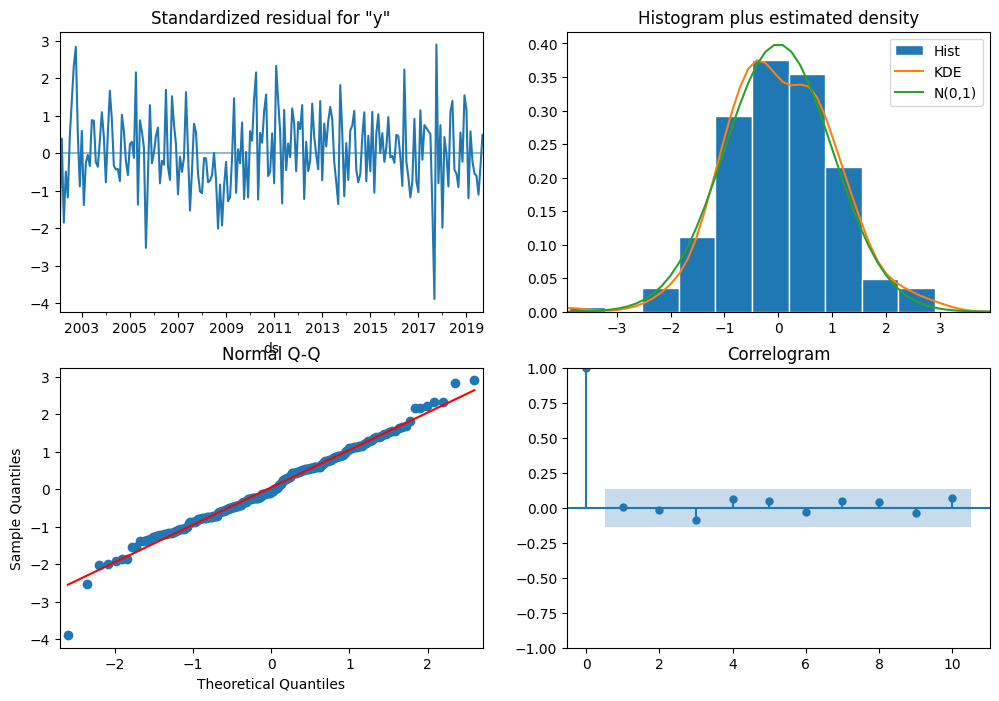

In [32]:
# Verificar ruido blanco
# Diagnostico del modelo
mejor_modelo.plot_diagnostics(figsize=(12,8))
plt.show()

## Pronóstico mejor modelo
Así, ahora contamos con un modelo ARIMA estacional que supera las verificaciones requeridas y está listo para realizar pronósticos. 
- Los pronósticos del modelo para los próximos tres años se muestran en la figura siguiente. 
- Los pronósticos han captado muy bien el patrón estacional, y la tendencia creciente extiende el patrón reciente. La tendencia en los pronósticos está inducida por la doble diferenciación.

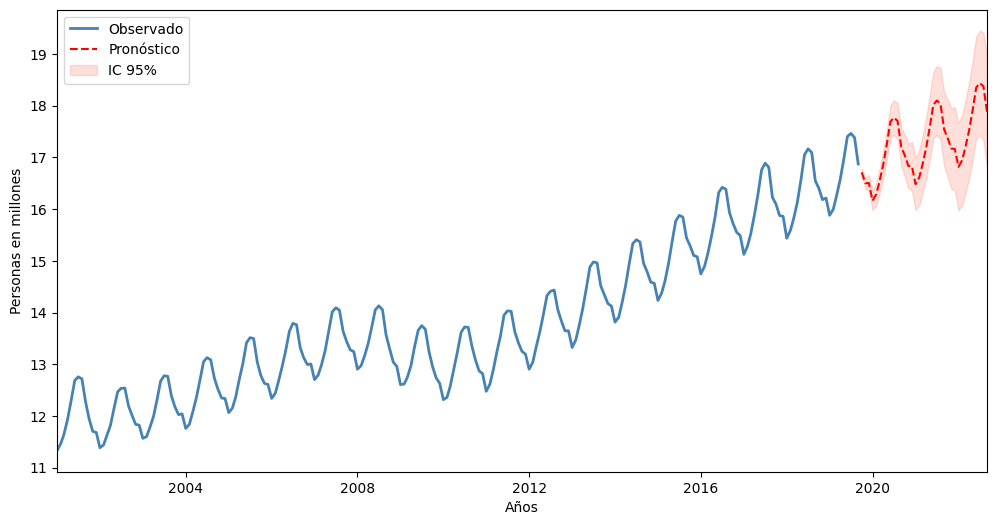

            Pronóstico  IC Inferior  IC Superior
Fecha                                           
2019-10-01   16.709419    16.636611    16.782226
2019-11-01   16.500122    16.387588    16.612656
2019-12-01   16.502774    16.351142    16.654406
2020-01-01   16.160839    15.975333    16.346344
2020-02-01   16.285072    16.069031    16.501113
2020-03-01   16.538814    16.295286    16.782343
2020-04-01   16.860148    16.591508    17.128788
2020-05-01   17.247247    16.955460    17.539034
2020-06-01   17.690610    17.377281    18.003939
2020-07-01   17.769798    17.436268    18.103328
2020-08-01   17.701607    17.349007    18.054207
2020-09-01   17.203965    16.833262    17.574667
2020-10-01   17.038289    16.635864    17.440714
2020-11-01   16.832417    16.397803    17.267031
2020-12-01   16.826258    16.358363    17.294154
2021-01-01   16.481451    15.981427    16.981475
2021-02-01   16.608186    16.077228    17.139145
2021-03-01   16.858908    16.298412    17.419403
2021-04-01   17.1823

In [33]:
# Pronostico de los proximos 3 años = 12 meses * 3 años  = 36
t_pronostico = 36
ultimo_dato  = serie_us_employment.index[-1]
anio_pronostico = pd.date_range(start=ultimo_dato + pd.offsets.MonthBegin(1), periods=t_pronostico, freq='MS')

# Obtener valores promedios e intervalos del pronostico
pronostico = mejor_modelo.get_forecast(steps=t_pronostico)
pred_mean = pronostico.predicted_mean
pred_ci = pronostico.conf_int()

# Alinear índice con la serie original
pred_mean.index = anio_pronostico
pred_ci.index   = anio_pronostico

# Graficar resultados pronostico
fig, ax = plt.subplots(figsize=(12, 6))
ax.plot(serie_us_employment.index, serie_us_employment, label="Observado", color='steelblue', linewidth=2)
ax.plot(pred_mean.index, pred_mean, label="Pronóstico", color='red', linestyle='--')
ax.fill_between(
    pred_ci.index,
    pred_ci.iloc[:, 0],
    pred_ci.iloc[:, 1],
    color='tomato', alpha=.2, label="IC 95%"
)
ax.set_xlim(pd.Timestamp('2001-01-01'), anio_pronostico[-1])
ax.set_xlabel('Años')
ax.set_ylabel('Personas en millones')
ax.legend()
plt.show()

# Tabla de pronóstico 
df_forecast = pd.DataFrame({
    "Pronóstico" : pred_mean,
    "IC Inferior" : pred_ci.iloc[:, 0],
    "IC Superior" : pred_ci.iloc[:, 1]
})
df_forecast.index.name = "Fecha"
print(df_forecast)

# Ejemplo 3 : El modelo macroeconómico del crecimiento del consumo en Estados Unidos

- Queremos modelar cómo cambia el consumo real (compra de bienes y servicios) de una economía según el incremento del ingreso.
$$
\Delta C_t = \beta_0 + \beta_1 \Delta Ingreso_t + \varepsilon_t
$$

- $\Delta C_t$ es el cambio porcentual en el gasto real de consumo personal.
- $Ingreso_t$​ es el cambio porcentual en el ingreso personal real disponible.

- Usar el archivo `US_change.csv` para modelar.

In [34]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from statsmodels.tsa.stattools import adfuller, kpss
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.stats.diagnostic import acorr_ljungbox
from statsmodels.tsa.arima.model import ARIMA
from pmdarima import auto_arima
from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.stats.stattools import jarque_bera, durbin_watson
import warnings
warnings.filterwarnings('ignore')

# leer y ajustar datos
# Cargar datos US_change
us_change = pd.read_csv("data/US_change.csv", parse_dates=["ds"])

# Formato
us_change["ds"] = pd.to_datetime(us_change["ds"])
us_change.set_index("ds", inplace=True)
us_change.index = pd.DatetimeIndex(us_change.index).to_period('Q').to_timestamp()

serie_consumo = us_change["y"]
serie_ingreso = us_change["Income"]

# Encabezado
us_change.head()

,y,Income,Production,Savings,Unemployment,unique_id
ds,,,,,,
1970-01-01,0.618566,1.044801,-2.452486,5.299014,0.9,US_change
1970-04-01,0.451984,1.225647,-0.551459,7.789894,0.5,US_change
1970-07-01,0.872872,1.585154,-0.358652,7.403984,0.5,US_change
1970-10-01,-0.271848,-0.239545,-2.185691,1.169898,0.7,US_change
1971-01-01,1.901345,1.975925,1.909764,3.535667,-0.1,US_change


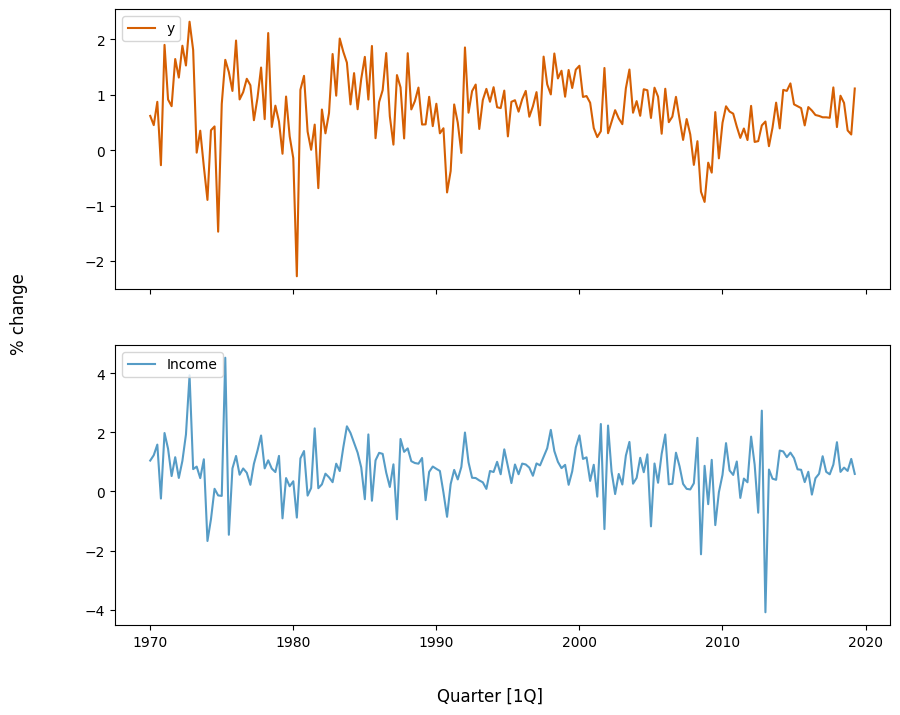

In [35]:
columns = ["y", "Income"]
colors = ["#D55F03", "#569CC6"]

fig, axes = plt.subplots(nrows=len(columns), ncols=1, sharex=True, figsize=(10, 8))
for i, var in enumerate(columns):
    axes[i].plot(us_change.index, us_change[var], label=var, color = colors[i])
    axes[i].legend(loc='upper left')
fig.supxlabel("Quarter [1Q]")
fig.supylabel("% change")
plt.show()

In [36]:
def test_estacionariedad(datos):
    # Augmented Dickey-Fuller
    adf_result = adfuller(datos)
    # KPSS
    kpss_result = kpss(datos, regression='c')

    # Tabla de resultados
    tab_test = pd.DataFrame({
        'Test'        : ["Prueba Augmented Dickey-Fuller (ADF)", "Prueba KPSS"],
        'Estadístico' : [round(adf_result[0],  4), round(kpss_result[0],  4)],
        'P-valor'     : [round(adf_result[1], 4), round(kpss_result[1], 4)],
        "Estacionario" : ["Sí" if adf_result[1] < 0.05 else "No", "No" if kpss_result[1] < 0.05 else "Sí"]
    })

    print("=" * 80)
    print("PRUEBA DE ESTACIONARIEDAD")
    print("=" * 80)
    print(tab_test)
    print("=" * 80)


print("Prueba consumo")
test_estacionariedad(serie_consumo)
print("\nPrueba ingreso")
test_estacionariedad(serie_ingreso)

Prueba consumo
PRUEBA DE ESTACIONARIEDAD
                                   Test  Estadístico  P-valor Estacionario
0  Prueba Augmented Dickey-Fuller (ADF)      -4.6101   0.0001           Sí
1                           Prueba KPSS       0.2212   0.1000           Sí

Prueba ingreso
PRUEBA DE ESTACIONARIEDAD
                                   Test  Estadístico  P-valor Estacionario
0  Prueba Augmented Dickey-Fuller (ADF)      -6.7656      0.0           Sí
1                           Prueba KPSS       0.1619      0.1           Sí


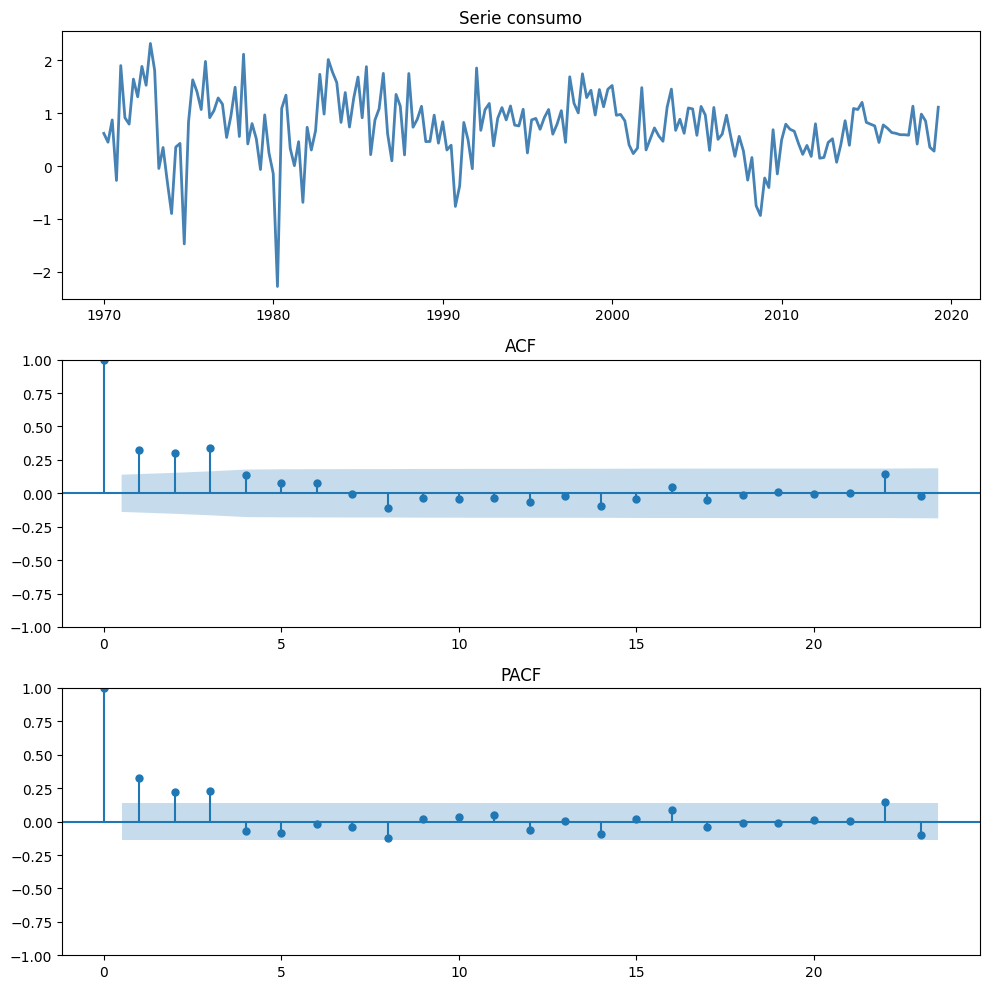

In [37]:
fig, axes = plt.subplots(3, 1, figsize=(10, 10))
axes[0].plot(serie_consumo.index, serie_consumo, color='steelblue', linewidth=2)
axes[0].set_title('Serie consumo')
plot_acf(serie_consumo, ax=axes[1], title=f'ACF')
plot_pacf(serie_consumo, ax=axes[2], title=f'PACF')
plt.tight_layout()
plt.show()

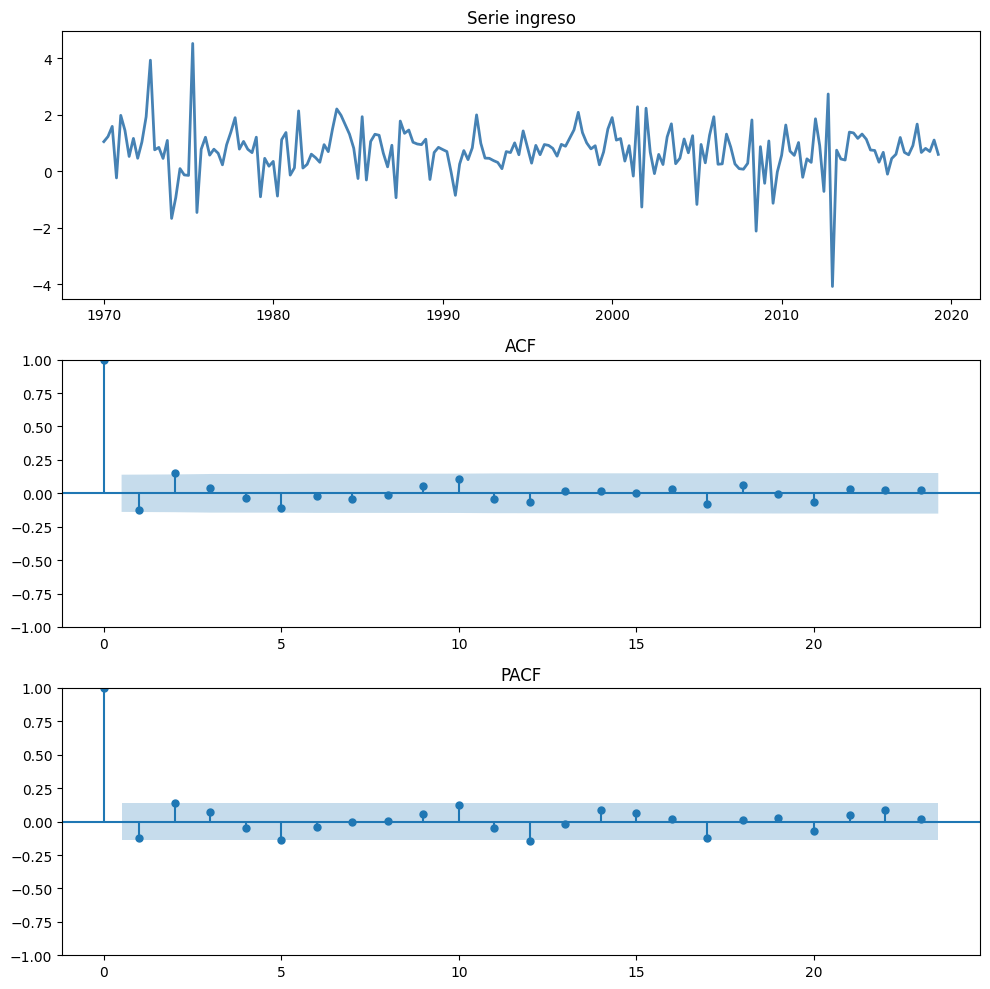

In [38]:
fig, axes = plt.subplots(3, 1, figsize=(10, 10))
axes[0].plot(serie_ingreso.index, serie_ingreso, color='steelblue', linewidth=2)
axes[0].set_title('Serie ingreso')
plot_acf(serie_ingreso, ax=axes[1], title=f'ACF')
plot_pacf(serie_ingreso, ax=axes[2], title=f'PACF')
plt.tight_layout()
plt.show()

In [39]:
# ARIMA(0, 0, 3)
arima003 = ARIMA(serie_consumo, exog=serie_ingreso, order=(0, 0, 3)).fit()
print(arima003.summary())

                               SARIMAX Results                                
Dep. Variable:                      y   No. Observations:                  198
Model:                 ARIMA(0, 0, 3)   Log Likelihood                -164.733
Date:                Fri, 10 Apr 2026   AIC                            341.465
Time:                        15:40:02   BIC                            361.195
Sample:                    01-01-1970   HQIC                           349.451
                         - 04-01-2019                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.6072      0.065      9.280      0.000       0.479       0.735
Income         0.1848      0.036      5.204      0.000       0.115       0.254
ma.L1          0.1192      0.066      1.801      0.0

In [40]:
# ARIMA(3, 0, 1)
arima301 = ARIMA(serie_consumo, exog=serie_ingreso, order=(3, 0, 1)).fit()
print(arima301.summary())

                               SARIMAX Results                                
Dep. Variable:                      y   No. Observations:                  198
Model:                 ARIMA(3, 0, 1)   Log Likelihood                -162.708
Date:                Fri, 10 Apr 2026   AIC                            339.415
Time:                        15:40:03   BIC                            362.433
Sample:                    01-01-1970   HQIC                           348.732
                         - 04-01-2019                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.6046      0.087      6.982      0.000       0.435       0.774
Income         0.1848      0.034      5.389      0.000       0.118       0.252
ar.L1          0.0451      0.344      0.131      0.8

In [41]:
# Autoarima
autoarima = auto_arima(serie_consumo, exog=serie_ingreso, d=0, sesional=False, trace = True, stepwise=False, approximation=False)

 ARIMA(0,0,0)(0,0,0)[1] intercept   : AIC=386.843, Time=0.01 sec
 ARIMA(0,0,1)(0,0,0)[1] intercept   : AIC=372.948, Time=0.02 sec
 ARIMA(0,0,2)(0,0,0)[1] intercept   : AIC=369.558, Time=0.05 sec
 ARIMA(0,0,3)(0,0,0)[1] intercept   : AIC=353.193, Time=0.05 sec
 ARIMA(0,0,4)(0,0,0)[1] intercept   : AIC=354.497, Time=0.07 sec
 ARIMA(0,0,5)(0,0,0)[1] intercept   : AIC=354.625, Time=0.08 sec
 ARIMA(1,0,0)(0,0,0)[1] intercept   : AIC=366.649, Time=0.02 sec
 ARIMA(1,0,1)(0,0,0)[1] intercept   : AIC=355.926, Time=0.07 sec
 ARIMA(1,0,2)(0,0,0)[1] intercept   : AIC=354.467, Time=0.08 sec
 ARIMA(1,0,3)(0,0,0)[1] intercept   : AIC=351.766, Time=0.08 sec
 ARIMA(1,0,4)(0,0,0)[1] intercept   : AIC=353.569, Time=0.13 sec
 ARIMA(2,0,0)(0,0,0)[1] intercept   : AIC=358.963, Time=0.03 sec
 ARIMA(2,0,1)(0,0,0)[1] intercept   : AIC=356.166, Time=0.07 sec
 ARIMA(2,0,2)(0,0,0)[1] intercept   : AIC=353.039, Time=0.13 sec
 ARIMA(2,0,3)(0,0,0)[1] intercept   : AIC=353.285, Time=0.17 sec
 ARIMA(3,0,0)(0,0,0)[1] i

In [42]:
# ARIMA optimo
auto_arima_optimo = ARIMA(serie_consumo, exog=serie_ingreso, order=autoarima.order).fit()
print(auto_arima_optimo.summary())

                               SARIMAX Results                                
Dep. Variable:                      y   No. Observations:                  198
Model:                 ARIMA(3, 0, 0)   Log Likelihood                -162.727
Date:                Fri, 10 Apr 2026   AIC                            337.454
Time:                        15:40:05   BIC                            357.183
Sample:                    01-01-1970   HQIC                           345.440
                         - 04-01-2019                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.6035      0.087      6.930      0.000       0.433       0.774
Income         0.1861      0.034      5.429      0.000       0.119       0.253
ar.L1          0.1081      0.065      1.663      0.0

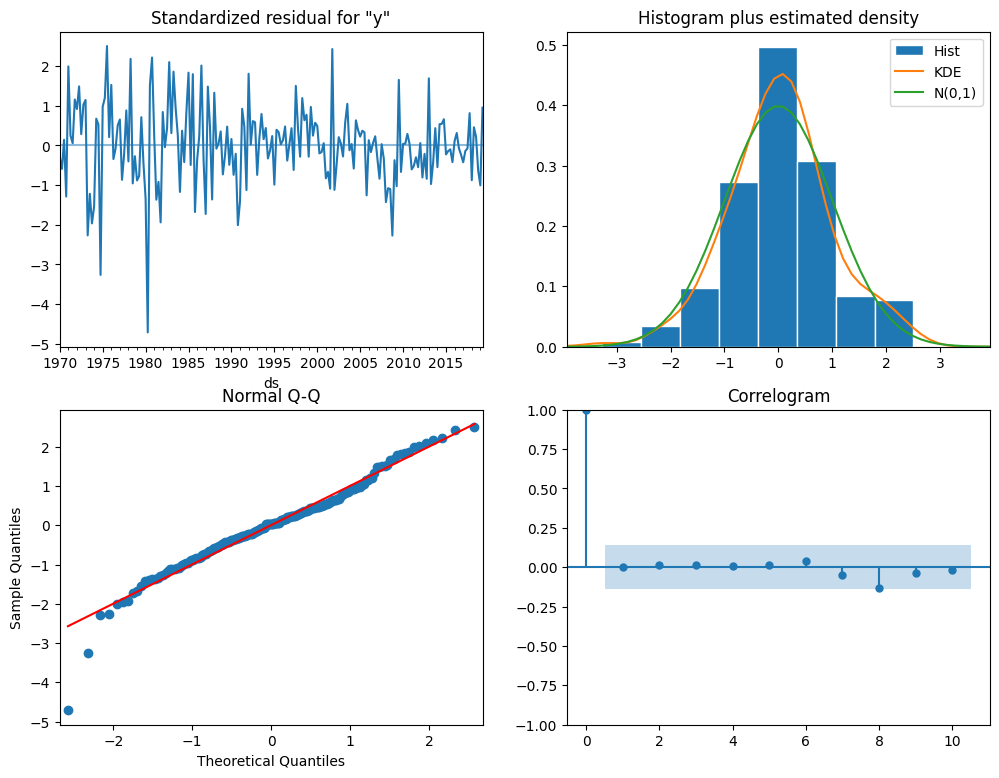

In [43]:
auto_arima_optimo.plot_diagnostics(figsize=(12, 9))
plt.show()

# Ejemplo 4 : Gasto en publicidad por televisión y cotizaciones de seguros

Una empresa de seguro en EEUU está interesada en saber si el gasto en publicidad por televisión influye en el valor de los aportes de aseguramiento. Para ello tiene dos series de tiempo, uno con el gasto en publicidad y la otra en aportes de seguro que realiza los clientes.

In [44]:
# librerias 
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from statsmodels.tsa.stattools import adfuller, kpss
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.stats.diagnostic import acorr_ljungbox
from statsmodels.tsa.arima.model import ARIMA
from pmdarima import auto_arima
from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.stats.stattools import jarque_bera, durbin_watson
from sklearn.metrics import mean_absolute_error, mean_squared_error, mean_absolute_percentage_error
import warnings
warnings.filterwarnings('ignore')

# Datos de seguros
seguros = pd.read_csv('data/insurance.csv', parse_dates=['ds'])
seguros = seguros.set_index('ds')
seguros.index = pd.DatetimeIndex(seguros.index).to_period('M').to_timestamp()
seguros.rename(columns={"Quotes" : "Aportes", "TVadverts" : "Gasto_publicidad"}, inplace=True)

# series
aportes = seguros.Aportes
gasto_publicidad = seguros.Gasto_publicidad

seguros.head()


,unique_id,Aportes,Gasto_publicidad
ds,,,
2002-01-01,insurance,12.97065,7.212725
2002-02-01,insurance,15.38714,9.443570
2002-03-01,insurance,13.22957,7.534250
2002-04-01,insurance,12.97065,7.212725
2002-05-01,insurance,15.38714,9.443570


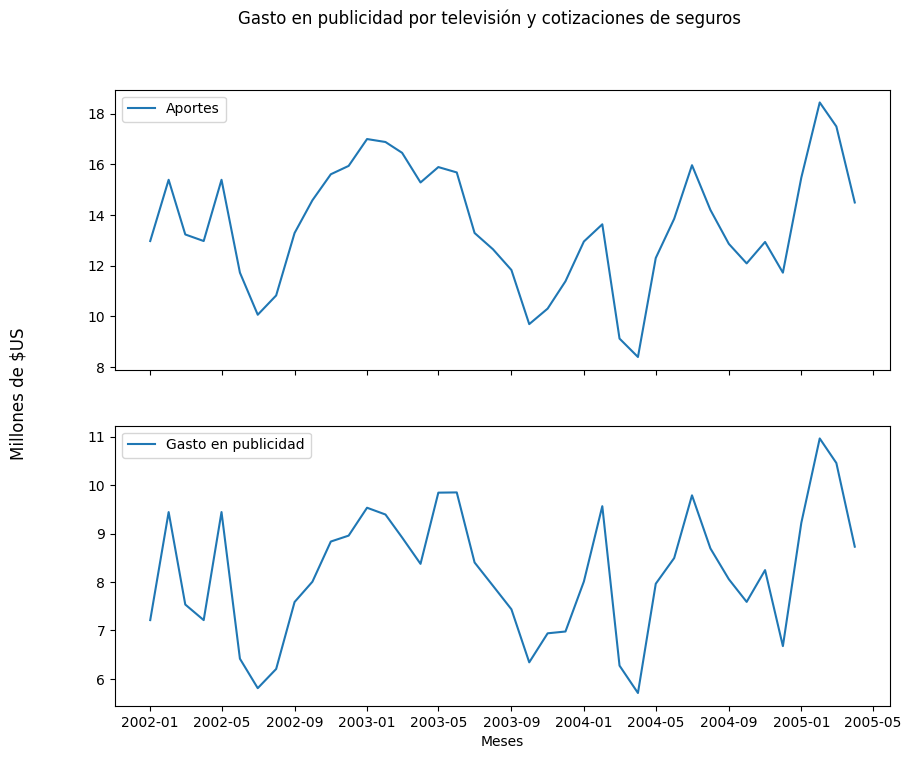

In [45]:
fig, axes = plt.subplots(2, figsize=(10, 8),  sharex=True)
axes[0].plot(seguros.index, seguros["Aportes"], label = "Aportes")
axes[0].legend(loc='upper left')
axes[1].plot(seguros.index, seguros["Gasto_publicidad"], label = "Gasto en publicidad")
axes[1].legend(loc='upper left')
axes[1].set(xlabel="Meses")
fig.suptitle("Gasto en publicidad por televisión y cotizaciones de seguros")
fig.supylabel("Millones de $US")
plt.show()

## EDA correlación series
- Correlación entre las series y sus rezagos en el gasto de publicidad  $Corr(y_t, x_{t-k})$

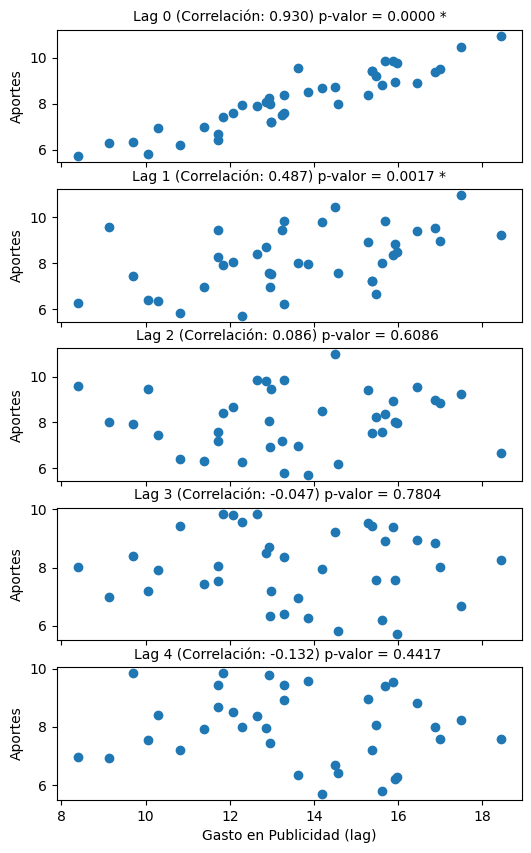

In [46]:
from scipy.stats import pearsonr

lags = range(5)
fig, axes = plt.subplots(nrows=len(lags), ncols=1, sharex=True, figsize=(6, 10))
for i in lags:
    gasto_publicidad_lag = gasto_publicidad.shift(i)
    index_notna = gasto_publicidad_lag.notna()
    aportes_info = aportes[index_notna]
    gasto_lag_info = gasto_publicidad_lag[index_notna]

    corr, p_valor = pearsonr(aportes_info, gasto_lag_info)
    sign_pvalor = "*" if p_valor < 0.05 else ""
    texto_info = f"Lag {i} (Correlación: {corr:.3f}) p-valor = {p_valor:.4f} {sign_pvalor}"

    axes[i].scatter(aportes, gasto_publicidad_lag)
    axes[i].set_title(texto_info, fontsize=10)
    axes[i].set_ylabel("Aportes")

    if i == lags[-1]:
        axes[i].set_xlabel("Gasto en Publicidad (lag)")
plt.show()

In [47]:
def test_estacionariedad(datos):
    # Augmented Dickey-Fuller
    adf_result = adfuller(datos)
    # KPSS
    kpss_result = kpss(datos, regression='c')

    # Tabla de resultados
    tab_test = pd.DataFrame({
        'Test'        : ["Prueba Augmented Dickey-Fuller (ADF)", "Prueba KPSS"],
        'Estadístico' : [round(adf_result[0],  4), round(kpss_result[0],  4)],
        'P-valor'     : [round(adf_result[1], 4), round(kpss_result[1], 4)],
        "Estacionario" : ["Sí" if adf_result[1] < 0.05 else "No", "No" if kpss_result[1] < 0.05 else "Sí"]
    })

    print("=" * 80)
    print("PRUEBA DE ESTACIONARIEDAD")
    print("=" * 80)
    print(tab_test)
    print("=" * 80)

test_estacionariedad(gasto_publicidad)
test_estacionariedad(aportes)

PRUEBA DE ESTACIONARIEDAD
                                   Test  Estadístico  P-valor Estacionario
0  Prueba Augmented Dickey-Fuller (ADF)      -4.2931   0.0005           Sí
1                           Prueba KPSS       0.1487   0.1000           Sí
PRUEBA DE ESTACIONARIEDAD
                                   Test  Estadístico  P-valor Estacionario
0  Prueba Augmented Dickey-Fuller (ADF)      -3.4231   0.0102           Sí
1                           Prueba KPSS       0.1006   0.1000           Sí


## Modelos :

- Modelo base sin rezago

$$
Aportes_t = \beta_0 + \beta_1 Publicidad_t + \eta_t \\
\eta_t \sim \text{ARMA(p, q)}
$$

- Modelo con 1 rezago

$$
Aportes_t = \beta_0 + \beta_1 Publicidad_t + \beta_2 Publicidad_{t - 1} + \eta_t \\
\eta_t \sim \text{ARMA(p, q)}
$$

- Modelo con 2 rezagos

$$
Aportes_t = \beta_0 + \beta_1 Publicidad_t + \beta_2 Publicidad_{t - 1} + \beta_3 Publicidad_{t - 2} + \eta_t \\
\eta_t \sim \text{ARMA(p, q)}
$$

- Modelo con 3 rezagos

$$
Aportes_t = \beta_0 + \beta_1 Publicidad_t + \beta_2 Publicidad_{t - 1} + \beta_3 Publicidad_{t - 2} +  \beta_4 Publicidad_{t - 3} + \eta_t \\
\eta_t \sim \text{ARMA(p, q)}
$$

> Como nuestro objetivo es comparar modelos, es **importante mantener el mismo set de entrenamiento** o estimación entre todos los modelos. Si no, estaremos comparando modelos con diferentes ventanas de estimación.

In [48]:
# Datos modelos rezagos 1-3
# Se crea un dataframe con los rezagos
n_rezagos = 3
datos_modelo = seguros.copy()
for i in range(1, n_rezagos + 1):
    datos_modelo[f"Gasto_publicidad_lag{i}"] = datos_modelo["Gasto_publicidad"].shift(i)

datos_modelo.dropna(inplace = True)
datos_modelo.head()

,unique_id,Aportes,Gasto_publicidad,Gasto_publicidad_lag1,Gasto_publicidad_lag2,Gasto_publicidad_lag3
ds,,,,,,
2002-04-01,insurance,12.97065,7.212725,7.534250,9.443570,7.212725
2002-05-01,insurance,15.38714,9.443570,7.212725,7.534250,9.443570
2002-06-01,insurance,11.72288,6.415215,9.443570,7.212725,7.534250
2002-07-01,insurance,10.06177,5.806990,6.415215,9.443570,7.212725
2002-08-01,insurance,10.82279,6.203600,5.806990,6.415215,9.443570


In [49]:
# modelo sin rezagos
auto_arimax_0 = auto_arima(y = datos_modelo["Aportes"], x = datos_modelo["Gasto_publicidad"], d= 0, sesional=False, trace = False)

# mejor modelo ARMA(p, q)
arimax_0 = ARIMA(seguros["Aportes"], exog=seguros["Gasto_publicidad"], order=auto_arimax_0.order).fit()
print(arimax_0.summary())

# guardar modelo
list_modelo_arimax = {"arimax_0" : arimax_0}

                               SARIMAX Results                                
Dep. Variable:                Aportes   No. Observations:                   40
Model:                 ARIMA(0, 0, 2)   Log Likelihood                 -31.454
Date:                Fri, 10 Apr 2026   AIC                             72.908
Time:                        15:40:08   BIC                             81.352
Sample:                    01-01-2002   HQIC                            75.961
                         - 04-01-2005                                         
Covariance Type:                  opg                                         
                       coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------------
const                3.7978      0.617      6.154      0.000       2.588       5.007
Gasto_publicidad     1.2012      0.064     18.762      0.000       1.076       1.327
ma.L1                1.2322 

In [50]:
# Modelo rezago 1-3
vars_rezagos = ["Gasto_publicidad"]
for i in range(1, n_rezagos + 1):
    vars_rezagos.append(f"Gasto_publicidad_lag{i}")    
    # autoarima
    auto_arimax_lag = auto_arima(y = datos_modelo["Aportes"], x = datos_modelo[vars_rezagos], d= 0, sesional=False, trace = False)
    # mejor modelo ARMA(p, q)
    fit_arimax_lag = ARIMA(datos_modelo["Aportes"], exog=datos_modelo[vars_rezagos], order=auto_arimax_lag.order).fit()
    # guardar modelo
    list_modelo_arimax[f"arimax_{i}"] = fit_arimax_lag

# print modelo con tres rezagos
print(list_modelo_arimax["arimax_3"].summary())


                               SARIMAX Results                                
Dep. Variable:                Aportes   No. Observations:                   37
Model:                 ARIMA(0, 0, 2)   Log Likelihood                 -24.808
Date:                Fri, 10 Apr 2026   AIC                             65.615
Time:                        15:40:10   BIC                             78.503
Sample:                    04-01-2002   HQIC                            70.159
                         - 04-01-2005                                         
Covariance Type:                  opg                                         
                            coef    std err          z      P>|z|      [0.025      0.975]
-----------------------------------------------------------------------------------------
const                     1.2342      2.235      0.552      0.581      -3.147       5.615
Gasto_publicidad          1.3536      0.089     15.126      0.000       1.178       1.529
Gasto_pu

In [51]:
# Comparacion de modelos
def comparar_modelos_arima(modelos: dict) -> pd.DataFrame:
    df_modelos = (
        pd.DataFrame({
            "Modelo"  : list(modelos),
            "Orden ARMA eta" : [m.model.order for m in modelos.values()],
            "AIC"     : [m.aic       for m in modelos.values()],
            "AICc"    : [m.aicc      for m in modelos.values()],
            "BIC"     : [m.bic       for m in modelos.values()],
            "Log-Lik" : [m.llf       for m in modelos.values()],
            "MSE"     : [m.mse       for m in modelos.values()],
            "RMSE"    : [m.mse**0.5  for m in modelos.values()],
            "MAE"     : [m.mae       for m in modelos.values()],
            "Params"  : [m.df_model  for m in modelos.values()],
            "Obs"     : [m.nobs      for m in modelos.values()],
        })
        .sort_values("AICc")
        .assign(Ranking=lambda df: range(1, len(df) + 1))
        .set_index("Ranking")
    )

    mejor      = df_modelos.iloc[0]["Modelo"]
    mejor_aicc = df_modelos.iloc[0]["AICc"]

    print("=" * 100)
    print("COMPARACIÓN DE MODELOS ARIMA")
    print("=" * 100)
    print(df_modelos.to_string())
    print("-" * 100)
    print(f"Mejor modelo (menor AICc): {mejor}  →  AICc: {mejor_aicc}")
    print("=" * 100)

comparar_modelos_arima(list_modelo_arimax)

COMPARACIÓN DE MODELOS ARIMA
           Modelo Orden ARMA eta        AIC       AICc        BIC    Log-Lik       MSE      RMSE       MAE  Params  Obs
Ranking                                                                                                                
1        arimax_1      (0, 0, 2)  61.816006  64.616006  71.481514 -24.908003  0.227671  0.477149  0.376609       6   37
2        arimax_2      (0, 0, 2)  63.812578  67.674647  75.089004 -24.906289  0.227750  0.477231  0.375938       7   37
3        arimax_3      (0, 0, 2)  65.615201  70.758059  78.502545 -24.807601  0.226312  0.475723  0.371228       8   37
4        arimax_0      (0, 0, 2)  72.907967  74.672673  81.352364 -31.453984  0.274048  0.523496  0.429802       5   40
----------------------------------------------------------------------------------------------------
Mejor modelo (menor AICc): arimax_1  →  AICc: 64.61600612931603


## Selección mejor modelo

- El mejor modelo (con el valor de AICc más pequeño) es lag 1 con dos predictores; es decir, incluye la publicidad únicamente en el mes actual y en el mes anterior. Por lo tanto, ahora reestimamos ese modelo, pero utilizando todos los datos disponibles.

$$
Aportes_t = 1.4007 + 1.3235 Publicidad_t + 0.1669 Publicidad_{t - 1} + \eta_t \\
\eta_t = 1.2716 \varepsilon_t + 0.7477 \varepsilon_{t-1} \\
\varepsilon_t \sim WN(0, 0.2094)
$$

- Intercepto (1.4007): Si no hubiera inversión en publicidad hoy ni ayer, se esperarían en promedio aproximadamente 1.40 unidades de aportes.

- Efecto inmmediato del gasto en publicidad (1.3235): Por cada unidad que aumente el gasto en publicidad hoy, los aportes aumentan en promedio 1.32 unidades.

- Efecto retardado del gasto en publicidad (0.1669): El gasto en publicidad del mes anterior aún tiene un efecto positivo residual en los aportes actuales.

- Error transferido ($\eta_t$​): Representa todo lo que afecta a los aportes que no es publicidad (ruido, competencia, etc.).Está compuesto por el choque aleatorio presente y un choque aleatorio del periodo anterior. Si hubo un evento inesperado el mes pasado, el 74.7% de ese efecto aún persiste en el error de este mes.- 

In [52]:
# set de datos completos
datos_modelo_final = seguros.copy()
datos_modelo_final["Gasto_publicidad_lag1"] = datos_modelo_final["Gasto_publicidad"].shift(1)
datos_modelo_final.dropna(inplace = True)

# Estimacion del modelo final
vars_rezagos = ["Gasto_publicidad", "Gasto_publicidad_lag1"]
auto_arimax_lag = auto_arima(y = datos_modelo_final["Aportes"], x = datos_modelo_final[vars_rezagos], d= 0, sesional=False, trace = False)
# mejor modelo ARMA(p, q)
mejor_arimax_lag = ARIMA(datos_modelo_final["Aportes"], exog=datos_modelo_final[vars_rezagos], order=auto_arimax_lag.order).fit()

# resultados
print(mejor_arimax_lag.summary())

                               SARIMAX Results                                
Dep. Variable:                Aportes   No. Observations:                   39
Model:                 ARIMA(0, 0, 2)   Log Likelihood                 -26.042
Date:                Fri, 10 Apr 2026   AIC                             64.085
Time:                        15:40:11   BIC                             74.066
Sample:                    02-01-2002   HQIC                            67.666
                         - 04-01-2005                                         
Covariance Type:                  opg                                         
                            coef    std err          z      P>|z|      [0.025      0.975]
-----------------------------------------------------------------------------------------
const                     1.4007      0.916      1.529      0.126      -0.395       3.196
Gasto_publicidad          1.3235      0.075     17.679      0.000       1.177       1.470
Gasto_pu

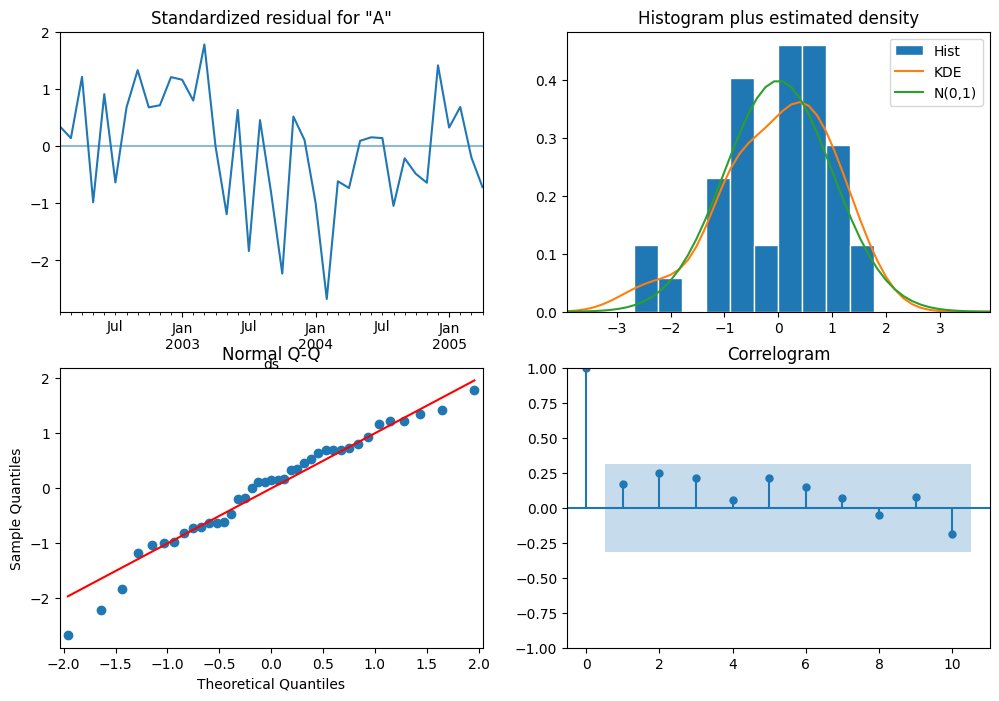

In [53]:
# Verificar ruido blanco
# Diagnostico del modelo
mejor_arimax_lag.plot_diagnostics(figsize=(12,8))
plt.show()

## Pronósticos
- Podemos calcular pronósticos utilizando este modelo si asumimos valores futuros para la variable de publicidad.
- Si fijamos la publicidad mensual futura en 8 unidades ¿Cúal sera el efecto en los aportes esperados en 8 meses?

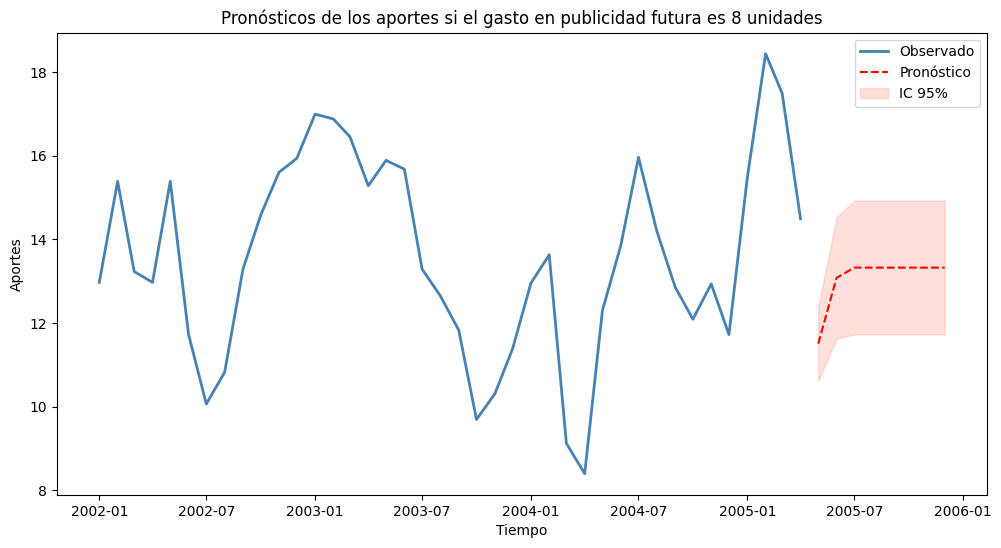

            Pronóstico  IC Inferior  IC Superior
Fecha                                           
2005-05-01   11.504685    10.607889    12.401481
2005-06-01   13.078513    11.627742    14.529284
2005-07-01   13.323668    11.725442    14.921895
2005-08-01   13.323668    11.725442    14.921895
2005-09-01   13.323668    11.725442    14.921895
2005-10-01   13.323668    11.725442    14.921895
2005-11-01   13.323668    11.725442    14.921895
2005-12-01   13.323668    11.725442    14.921895


In [54]:
# Pronostico de los proximos 8 meses
ult_fecha = seguros.index[-1]
fechas_futuras = pd.date_range(start=ult_fecha + pd.offsets.MonthBegin(1), periods=8, freq='MS')

# fijar publicidad en 8
gasto_publicidad_pronostico = pd.DataFrame({'Gasto_publicidad': [8] * 8}, index=fechas_futuras)
gasto_publicidad_pronostico["Gasto_publicidad_lag1"] = gasto_publicidad_pronostico["Gasto_publicidad"].shift(1)
gasto_publicidad_pronostico.fillna(0, inplace=True) # IMPORTANTE, get_forecast no acepta NaN en las variables exogenas

# Generar el pronóstico
pronostico = mejor_arimax_lag.get_forecast(steps=8, exog=gasto_publicidad_pronostico)
pred_mean = pronostico.predicted_mean
pred_ci = pronostico.conf_int()

# Graficar
fig, ax = plt.subplots(figsize=(12, 6))
ax.plot(seguros.index, seguros["Aportes"], label="Observado", color='steelblue', linewidth=2)
ax.plot(pred_mean.index, pred_mean, label="Pronóstico", color='red', linestyle='--')
ax.fill_between(
    pred_ci.index,
    pred_ci.iloc[:, 0],
    pred_ci.iloc[:, 1],
    color='tomato', alpha=.2, label="IC 95%"
)
ax.set_xlabel('Tiempo')
ax.set_ylabel('Aportes')
ax.legend()
plt.title('Pronósticos de los aportes si el gasto en publicidad futura es 8 unidades')
plt.show()

# Tabla de pronóstico 
df_forecast = pd.DataFrame({
    "Pronóstico" : pred_mean,
    "IC Inferior" : pred_ci.iloc[:, 0],
    "IC Superior" : pred_ci.iloc[:, 1]
})
df_forecast.index.name = "Fecha"
print(df_forecast)
